In [33]:
import numpy as np
import moments 
import pandas
import matplotlib.pyplot as plt 
import matplotlib 
import msprime
import demes 
import demesdraw
import scipy
from matplotlib.transforms import ScaledTranslation

In [34]:
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}\usepackage{amssymb}"
matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif'] = "Computer Modern"
matplotlib.rcParams['savefig.bbox'] = "tight"
matplotlib.rcParams['axes.linewidth'] = 0.5
lw = 0.8

In [35]:
def get_structure_model(params):
    N0, N1, N2, T0, T1, p, m = params
    builder = demes.Builder()
    builder.add_deme("Anc", epochs=[{"start_size": N0, "end_time": T0}])
    builder.add_deme("X", ancestors=["Anc"], 
                     epochs=[{"start_size": N1, "end_time": T1}])
    builder.add_deme("Y", ancestors=["Anc"], 
                     epochs=[{"start_size": N2, "end_time": T1}])
    builder.add_deme("A", ancestors=["X", "Y"], proportions=[p, 1-p],
                     start_time=T1, 
                     epochs=[{"start_size": N0, "end_time": 0}])
    builder.add_migration(rate=m, demes=["X", "Y"])
    graph = builder.resolve()
    return graph


def compute_rate_trajectory(graph, ts, sample):
    demog = msprime.Demography.from_demes(graph)
    debug = demog.debug()
    rates, _ = debug.coalescence_rate_trajectory(ts, {sample: 2})
    return rates


def get_panmictic_model(ts, rates):
    Nes = 1 / (2 * np.array(rates))
    _ts = np.flip(ts)
    _Nes = np.flip(Nes)
    epochs = [
        {"start_size": Ne, "end_time": t} for Ne, t in zip(_Nes, _ts)
    ]
    builder = demes.Builder()
    builder.add_deme("A", epochs=epochs)
    graph = builder.resolve()
    return graph


In [36]:
ts = np.linspace(0, 2.5e4, 301)
structure_model0 = get_structure_model([1e4, 5e3, 5e3, 2.2e4, 2e3, 0.50, 0])
rates0 = compute_rate_trajectory(structure_model0, ts, "A")
panmictic_model0 = get_panmictic_model(ts, rates0)

structure_model1 = get_structure_model([1e4, 5e3, 5e3, 2.2e4, 2e3, 0.50, 1.5e-5])
rates1 = compute_rate_trajectory(structure_model1, ts, "A")
panmictic_model1 = get_panmictic_model(ts, rates1)

structure_model2 = get_structure_model([1e4, 5e3, 5e3, 2.2e4, 2e3, 0.50, 5e-5])
rates2 = compute_rate_trajectory(structure_model2, ts, "A")
panmictic_model2 = get_panmictic_model(ts, rates2)


rs = np.logspace(-6, -2, 31)
u = 1e-8
struc_yy0 = moments.Demes.LD(structure_model0, sampled_demes=["A"], r=rs, u=u)
struc_yy1 = moments.Demes.LD(structure_model1, sampled_demes=["A"], r=rs, u=u)
struc_yy2 = moments.Demes.LD(structure_model2, sampled_demes=["A"], r=rs, u=u)
pan_yy0 = moments.Demes.LD(panmictic_model0, sampled_demes=["A"], r=rs, u=u)
pan_yy1 = moments.Demes.LD(panmictic_model1, sampled_demes=["A"], r=rs, u=u)
pan_yy2 = moments.Demes.LD(panmictic_model2, sampled_demes=["A"], r=rs, u=u)

KeyboardInterrupt: 

In [ ]:
hn0 = []
for i in range(5):
    tbl0 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/hn_0_nullmodel_rep_{i}.csv")
    tbl1 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/hn_0_pulsemodel_rep_{i}.csv")
    hn0.append(2 * (np.array(tbl1["ll"]) - np.array(tbl0["ll"])))

hn1 = []
for i in range(5):
    tbl0 = pandas.read_csv(f"../simulations/power_analysis/extra_boot_fits/tables/hn_0.01_nullmodel_rep_{i}.csv")
    tbl1 = pandas.read_csv(f"../simulations/power_analysis/extra_boot_fits/tables/hn_0.01_pulsemodel_rep_{i}.csv")
    hn1.append(2 * (np.array(tbl1["ll"]) - np.array(tbl0["ll"])))

hn2 = []
for i in range(5):
    tbl0 = pandas.read_csv(f"../simulations/power_analysis/extra_boot_fits/tables/hn_0.02_nullmodel_rep_{i}.csv")
    tbl1 = pandas.read_csv(f"../simulations/power_analysis/extra_boot_fits/tables/hn_0.02_pulsemodel_rep_{i}.csv")
    hn2.append(2 * (np.array(tbl1["ll"]) - np.array(tbl0["ll"])))

hn3 = []
for i in range(5):
    tbl0 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/hn_0.03_nullmodel_rep_{i}.csv")
    tbl1 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/hn_0.03_pulsemodel_rep_{i}.csv")
    hn3.append(2 * (np.array(tbl1["ll"]) - np.array(tbl0["ll"])))

hn5 = []
for i in range(5):
    tbl0 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/hn_0.05_nullmodel_rep_{i}.csv")
    tbl1 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/hn_0.05_pulsemodel_rep_{i}.csv")
    hn5.append(2 * (np.array(tbl1["ll"]) - np.array(tbl0["ll"])))


sd0 = []
for i in range(5):
    tbl0 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/gd_0_nullmodel_rep_{i}.csv")
    tbl1 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/gd_0_pulsemodel_rep_{i}.csv")
    sd0.append(2 * (np.array(tbl1["ll"]) - np.array(tbl0["ll"])))

sd1 = []
for i in range(5):
    tbl0 = pandas.read_csv(f"../simulations/power_analysis/extra_boot_fits/tables/gd_0.01_nullmodel_rep_{i}.csv")
    tbl1 = pandas.read_csv(f"../simulations/power_analysis/extra_boot_fits/tables/gd_0.01_pulsemodel_rep_{i}.csv")
    sd1.append(2 * (np.array(tbl1["ll"]) - np.array(tbl0["ll"])))

sd2 = []
for i in range(5):
    tbl0 = pandas.read_csv(f"../simulations/power_analysis/extra_boot_fits/tables/gd_0.02_nullmodel_rep_{i}.csv")
    tbl1 = pandas.read_csv(f"../simulations/power_analysis/extra_boot_fits/tables/gd_0.02_pulsemodel_rep_{i}.csv")
    sd2.append(2 * (np.array(tbl1["ll"]) - np.array(tbl0["ll"])))

sd3 = []
for i in range(5):
    tbl0 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/gd_0.03_nullmodel_rep_{i}.csv")
    tbl1 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/gd_0.03_pulsemodel_rep_{i}.csv")
    sd3.append(2 * (np.array(tbl1["ll"]) - np.array(tbl0["ll"])))

sd5 = []
for i in range(5):
    tbl0 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/gd_0.05_nullmodel_rep_{i}.csv")
    tbl1 = pandas.read_csv(f"../simulations/power_analysis/boot_fits/tables/gd_0.05_pulsemodel_rep_{i}.csv")
    sd5.append(2 * (np.array(tbl1["ll"]) - np.array(tbl0["ll"])))

In [ ]:
def make_coal_rate_plot(ax):
    xs = ts / 2e4
    ax.plot([], [], color="black", lw=lw, label="structured")
    ax.plot(xs, rates0, color="tab:blue", lw=lw)
    ax.plot(xs, rates1, color="tab:orange", lw=lw)
    ax.plot(xs, rates2, color="tab:green", lw=lw)

    _ts = np.linspace(0, 2.5e4, 31)
    pan_rates0 = compute_rate_trajectory(panmictic_model0, _ts, "A")
    pan_rates1 = compute_rate_trajectory(panmictic_model1, _ts, "A")
    pan_rates2 = compute_rate_trajectory(panmictic_model2, _ts, "A")
    _xs = _ts / 2e4
    ax.plot([], [], "--o", color="black", lw=lw, label="panmictic", markersize=3)
    ax.scatter(_xs, pan_rates0, color="tab:blue", s=10, lw=lw)
    ax.scatter(_xs, pan_rates1, color="tab:orange", s=10, lw=lw)
    ax.scatter(_xs, pan_rates2, color="tab:green", s=10, lw=lw)
    ax.set_xlabel("$t$")
    ax.set_ylabel(r"$\lambda(t)$")
    ax.legend(framealpha=0, loc="upper center")
    ax.set_xlim(0, )
    ax.set_yticks([2e-5, 3e-5, 4e-5, 5e-5])
    ax.annotate("$M=0$", (0.85, 1.95e-5), color="tab:blue")
    ax.annotate("$M=0.3$", (0.85, 3e-5), color="tab:orange")
    ax.annotate("$M=1$", (0.85, 4.1e-5), color="tab:green")
    ax.set_xlim(0, xs[-1])
    return


def make_curves_plot(ax):
    inset = ax.inset_axes([0.60, 0.57, 0.38, 0.40])
    plot_model = get_structure_model([1e4, 5e3, 5e3, 2.3e4, 3e3, 0.50, 1.5e-5])
    demesdraw.tubes(
        plot_model, ax=inset, colours="tab:blue", fill=True, labels=None,
        inf_ratio=0.1, positions={"Anc": 0, "X": -1.4e4, "Y": 1.4e4, "A": 0})
    inset.spines["top"].set_visible(True)
    inset.spines["right"].set_visible(True)
    inset.spines["bottom"].set_visible(True)
    inset.set_ylabel("$t$")
    inset.set_yticks([0, 5e3, 2.5e4], ["0", "$T_1$", "$T_0$"])
    inset.set_yticks([0, 3e3, 2.2e4], [0, 0.1, 1.1])

    rhos = 4 * 1e4 * rs
    ax.plot(rhos, struc_yy0.H2(0), lw=lw, color="tab:blue")
    ax.plot(rhos, struc_yy1.H2(0), lw=lw, color="tab:orange")
    ax.plot(rhos, struc_yy2.H2(0), lw=lw, color="tab:green")

    ax.plot(rhos, pan_yy0.H2(0), "--", color="tab:blue", lw=lw)
    ax.plot(rhos, pan_yy1.H2(0), "--", color="tab:orange", lw=lw)
    ax.plot(rhos, pan_yy2.H2(0), "--", color="tab:green", lw=lw)
    ax.scatter(rhos, pan_yy0.H2(0), color="tab:blue", s=10, lw=lw)
    ax.scatter(rhos, pan_yy1.H2(0), color="tab:orange", s=10, lw=lw)
    ax.scatter(rhos, pan_yy2.H2(0), color="tab:green", s=10, lw=lw)
    ax.set_xscale("log")
    ax.minorticks_off()
    ax.set_ylabel(r"$\mathbb{E}[D^+]$")
    ax.set_xlabel(r"$\rho$")
    ax.set_yticks([2e-7, 3e-7, 4e-7])
    return

In [ ]:
sd0 = pandas.read_csv(f"../simulations/power_analysis/boot_fits_full/tables/gd_0_pulsemodel_rep_2.csv")["DLL"]
sd1 = pandas.read_csv(f"../simulations/power_analysis/boot_fits_full/tables/gd_0.01_pulsemodel_rep_1.csv")["DLL"]
sd2 = pandas.read_csv(f"../simulations/power_analysis/boot_fits_full/tables/gd_0.02_pulsemodel_rep_2.csv")["DLL"]
sd3 = pandas.read_csv(f"../simulations/power_analysis/boot_fits_full/tables/gd_0.03_pulsemodel_rep_0.csv")["DLL"]

hn0 = pandas.read_csv(f"../simulations/power_analysis/boot_fits_full/tables/hn_0_pulsemodel_rep_2.csv")["DLL"]
hn1 = pandas.read_csv(f"../simulations/power_analysis/boot_fits_full/tables/hn_0.01_pulsemodel_rep_3.csv")["DLL"]
hn2 = pandas.read_csv(f"../simulations/power_analysis/boot_fits_full/tables/hn_0.02_pulsemodel_rep_1.csv")["DLL"]
hn3 = pandas.read_csv(f"../simulations/power_analysis/boot_fits_full/tables/hn_0.03_pulsemodel_rep_0.csv")["DLL"]

In [43]:
_lw = 1

def make_human_neand_sim_plot(ax):
    inset = ax.inset_axes([0.45, 0.5, 0.52, 0.47])
    graph = demes.load("../simulations/power_analysis/models/model_hn_0.10.yaml")
    demesdraw.tubes(graph, ax=inset, colours="tab:blue", fill=True, labels=None,
        positions={"Anc": 0, "Yor": -4e4, "ND": 3e4, "Nea": 1e4, "Den": 5e4})
    inset.set_xticks([-4e4, 1e4, 5e4], ["Yor", "N", "D"])
    inset.spines["top"].set_visible(True)
    inset.spines["right"].set_visible(True)
    inset.spines["bottom"].set_visible(True)
    inset.set_ylabel("$t$")
    times = np.array([0, 1,])
    _times = times * 2 * 1.6e4 * 29
    inset.set_yticks(_times, times)

    thresh = scipy.stats.chi2.ppf(0.95, 2)
    bins = np.concat([[0, thresh], np.linspace(thresh, 300, 40)[1:]])
    ax.step(np.append(bins, bins[-1]), 
            np.concat(([0], (np.histogram(hn0, bins=bins)[0] / len(hn0)), [0])),
            lw=lw, color="tab:blue", label="$f=0$")
    ax.step(bins, 
            np.concat(([0], (np.histogram(hn1, bins=bins)[0] / len(hn0)))),
            lw=lw, color="tab:orange", label="$f=0.01$")
    ax.step(bins, 
            np.concat(([0], (np.histogram(hn2, bins=bins)[0] / len(hn0)))),
            lw=lw, color="tab:green", label="$f=0.02$")
    ax.step(np.append(bins, bins[-1]), 
            np.concat(([0], (np.histogram(hn3, bins=bins)[0] / len(hn0)), [0])),
            lw=lw, color="tab:red", label="$f=0.03$")
    ax.vlines(thresh, 0, 1, color="black", lw=0.7,
        transform=ax.get_xaxis_transform(), linestyle="--")
    ax.set_ylim(0, )
    ax.legend(framealpha=0, bbox_to_anchor=(0.6, 0.1))
    ax.set_ylabel("Frequency")
    ax.set_xlabel("LRT statistic")
    return 


def make_ghost_den_sim_plot(ax):
    inset = ax.inset_axes([0.45, 0.5, 0.52, 0.47])
    graph = demes.load("../simulations/power_analysis/models/model_gd_0.10.yaml")
    demesdraw.tubes(
        graph, ax=inset, colours="tab:blue", fill=True, labels=None,inf_ratio=0.1,
        positions={"Anc": 0, "Yor": -4e4, "ND": 3e4, "Nea": 1e4, "Den": 5e4,
                   "Ghost": 9e4})
    inset.set_xticks([-4e4, 1e4, 5e4, 9e4], ["Yor", "N", "D", "Sup"])
    inset.spines["top"].set_visible(True)
    inset.spines["right"].set_visible(True)
    inset.spines["bottom"].set_visible(True)
    inset.set_ylabel("$t$")
    times = np.array([0, 1, 2])
    _times = times * 2 * 1.6e4 * 29
    inset.set_yticks(_times, times)

    thresh = scipy.stats.chi2.ppf(0.95, 1)
    bins = np.sort(np.concatenate([[thresh], np.linspace(0, 300, 40)]))

    ax.step(np.append(bins, bins[-1]), 
            np.concat(([0], (np.histogram(sd0, bins=bins)[0] / len(sd0)), [0])),
            lw=lw, color="tab:blue", label="$f=0$")
    ax.step(bins, 
            np.concat(([0], (np.histogram(sd1, bins=bins)[0] / len(sd1)))),
            lw=lw, color="tab:orange", label="$f=0.01$")
    ax.step(bins, 
            np.concat(([0], (np.histogram(sd2, bins=bins)[0] / len(sd2)))),
            lw=lw, color="tab:green", label="$f=0.02$")
    ax.step(np.append(bins, bins[-1]), 
            np.concat(([0], (np.histogram(sd3, bins=bins)[0] / len(sd3)), [0])),
            lw=lw, color="tab:red", label="$f=0.03$")
    ax.vlines(thresh, 0, 1, color="black", lw=0.7,
        transform=ax.get_xaxis_transform(), linestyle="--")
    ax.set_ylim(0, )
    ax.legend(framealpha=0, bbox_to_anchor=(0.6, 0.1))
    ax.set_ylabel("Frequency")
    ax.set_xlabel("LRT statistic")
    return

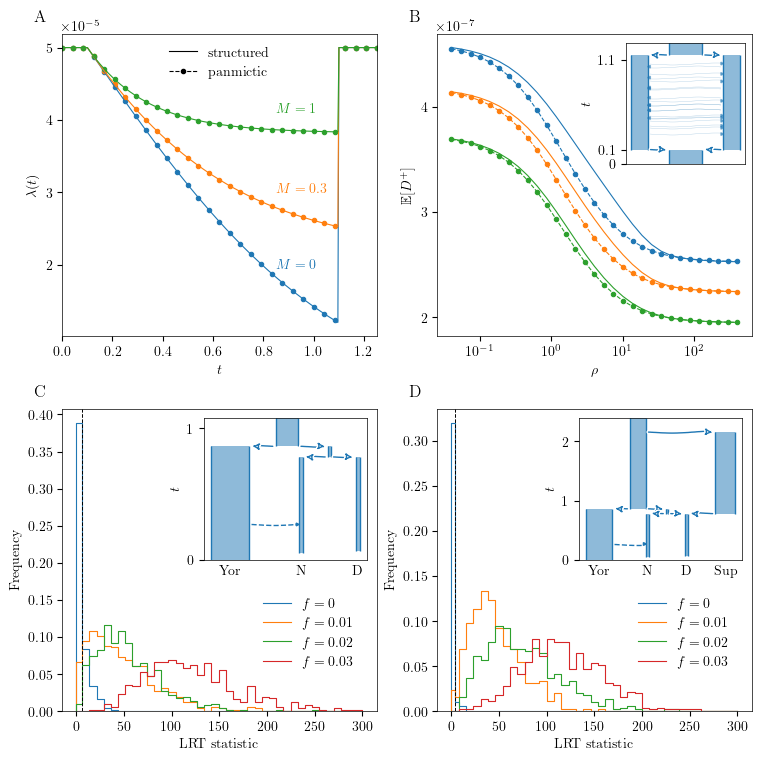

In [44]:
mosaic = "AB;CD"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7.5, 7.5), layout="constrained")
for label, ax in axs.items():
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))
make_human_neand_sim_plot(axs["C"])
make_ghost_den_sim_plot(axs["D"])
make_coal_rate_plot(axs["A"])
make_curves_plot(axs["B"])
plt.savefig("figures/fig2.pdf")